<a href="https://colab.research.google.com/github/peremartra/Rearchitecting-LLMs/blob/main/CH04/CH04_NB01_wiki.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table style="width:100%; border:none; background:none;">
  <tr style="border:none;">
    <td style="border:none; vertical-align:middle; text-align:left; width: 120px;">
      <a href="https://hubs.la/Q040tvsK0"><img src="https://raw.githubusercontent.com/peremartra/Rearchitecting-LLMs/main/Images/cover.png" width="100px" style="border-radius: 4px;"></a>
    </td>
    <td style="border:none; vertical-align:middle; text-align:left;">
      <p style="margin: 0; font-size: 14px;">
        Supplementary code for the <a href="https://hubs.la/Q040tvsK0">Rearchitecting LLMs</a> book by <a href="https://github.com/peremartra">Pere Martra</a>.<br>
        <br>
        Code repository: <a href="https://github.com/peremartra/Rearchitecting-LLMs">https://github.com/peremartra/Rearchitecting-LLMs</a>
      </p>
    </td>
  </tr>
</table>

#Rearchitecting LLMs
## Structural techniques for efficient models


### Chapter 4: Depth Pruning: Building Smaller and Faster Models

[![LinkedIn](https://img.shields.io/badge/LinkedIn-0077B5?style=flat&logo=linkedin&logoColor=white)](https://www.linkedin.com/in/pere-martra/) [![GitHub](https://img.shields.io/badge/GitHub-100000?style=flat&logo=github&logoColor=white)](https://github.com/peremartra) [![X](https://img.shields.io/badge/X-000000?style=flat&logo=x&logoColor=white)](https://x.com/PereMartra) [![Hugging Face](https://img.shields.io/badge/🤗%20Hugging%20Face-blue)](https://huggingface.co/oopere)

_____
Colab Environment: GPU T4

Models:
* Qwen3-0.6B
_____

In this notebook we explore how to evaluate the contribution of different transformer blocks to the LLM's objective using a dataset.

To do this, we use cosine similarity between the input and the output of the transformer block. The lower the similarity, the greater the modification that block has introduced to the data.

Blocks with higher similarity between input and output will be the candidates to be removed from the model.

# Setting up notebook

In [1]:
!pip install -q \
      "transformers==4.55.4" \
      "accelerate==1.10.1" \
      "lm_eval==0.4.9.1" \
      "sentencepiece==0.2.1" \
      "sentence-transformers==5.1.0" \
      "datasets==3.5.0" \
      "optipfair==0.1.5"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 112.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.9/374.9 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 78.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 483.4/483.4 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 41.9 MB/s eta 0:00:00

In [2]:
import torch, random
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer, set_seed
from datasets import load_dataset
from torch.utils.data import DataLoader
from tqdm import tqdm
import numpy as np
from lm_eval import evaluator
from lm_eval.models.huggingface import HFLM
import os
import json
from optipfair import analyze_layer_importance, prune_model_depth, prune_model

In [3]:
def set_reproducibility(seed=42):
    # 1. Seed for Python and basic libraries
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

    # 2. Seed for PyTorch (CPU and GPU)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # For multi-GPU

    # 3. Configure cuDNN to be deterministic
    # Note: This may slow down training slightly
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # 4. Seed for Transformers (Hugging Face)
    set_seed(seed)

    print(f"✅ Seed {seed} stablished.")

set_reproducibility(42)

✅ Seed 42 stablished.


In [4]:
# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


In [5]:
def evaluate_metrics(model, dataloader, device='cuda'):
    model.eval()
    model.to(device)

    total_loss = 0
    total_tokens = 0

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            # Create labels, ignoring padding (-100 = ignore_index)
            labels = input_ids.clone()
            labels[attention_mask == 0] = -100

            # Forward pass
            outputs = model(
                input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            # Only real tokens (no padding)
            num_real_tokens = attention_mask.sum().item()

            total_loss += outputs.loss.item() * num_real_tokens
            total_tokens += num_real_tokens

    # metrics
    avg_loss = total_loss / total_tokens
    perplexity = np.exp(avg_loss)

    return {
        'loss': avg_loss,
        'perplexity': perplexity
    }

## Load Model

In [6]:
MODEL_NAME = 'Qwen/Qwen3-0.6B'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)
model.eval()
model.generation_config.temperature = None
model.generation_config.top_p = None
model.generation_config.top_k = None

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

## Load Datasets

In [7]:
RECOVERY_SAMPLES = 1000
BATCH_SIZE = 4
MAX_LENGTH = 512

We’re going to use two different datasets to visualize how some layers are more important than others depending on the data being used.

* **Wikitext**: Contains highly complex text. To process this kind of text, the model needs to rely on its deeper layers to understand context, semantic relations, and complex grammatical structures.
* **SMS Spam**: A completely different dataset, made up of short sentences with simple and direct language. It doesn’t require deep semantic understanding.


In [8]:
datawiki = load_dataset('wikitext', 'wikitext-2-raw-v1', split=f'train[:{RECOVERY_SAMPLES}]')

datasms = load_dataset('sms_spam', split=f'train[:{RECOVERY_SAMPLES}]')

README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/359k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5574 [00:00<?, ? examples/s]

In [9]:
def prepare_dataset(dataset, text_field='text'):
    def tokenize_function(examples):
        if text_field in examples:
            texts = examples[text_field]
        elif 'sms' in examples:
            texts = examples['sms']
        elif 'text' in examples:
            texts = examples['text']
        else:
            texts = examples[list(examples.keys())[0]]

        return tokenizer(
            texts,
            truncation=True,
            padding='max_length',
            max_length=MAX_LENGTH,
            return_tensors=None  # Listas, no tensores — evita el torch_formatter
        )

    tokenized = dataset.map(tokenize_function, batched=True, remove_columns=dataset.column_names)

    # Convertimos a tensores manualmente en el collate_fn,
    # evitando el formatter de datasets que tiene el bug de VideoReader
    def collate_fn(examples):
        input_ids = torch.tensor([e['input_ids'] for e in examples], dtype=torch.long)
        attention_mask = torch.tensor([e['attention_mask'] for e in examples], dtype=torch.long)
        return {'input_ids': input_ids, 'attention_mask': attention_mask}

    return DataLoader(tokenized, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

In [10]:
# Crear dataloaders
dataloaderwiki = prepare_dataset(datawiki)  # WikiText (largo)
dataloadersms = prepare_dataset(datasms)  # SMS (corto)

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

# 4.3 Data-Driven block selection

To decide which layers to remove, we measure their contribution using cosine similarity. We chose this metric because it’s perfect for this task: it measures the change in semantic direction between the input and output vectors of a layer, ignoring their magnitude.

This gives us a normalized score that we convert into an importance score (1 - similarity).

A score close to zero identifies a “passive” layer that barely alters the information, making it an ideal candidate for removal.


### Calculate Cosine Similarity

In [12]:
def calculate_cosine_importance(input_tensor, output_tensor, attention_mask, layer_idx, is_first_batch=False):
    """
    Computes the importance score of an attention sublayer for a single batch,
    properly masking out padding tokens to prevent artificial similarity inflation.
    """
    if input_tensor.numel() == 0 or output_tensor.numel() == 0:
        return 0.0

    # Calculate cosine similarity along the hidden state dimension (dim=-1)
    # Tensors shape: [batch_size, seq_len, hidden_size] -> similarities shape: [batch_size, seq_len]
    similarities = F.cosine_similarity(input_tensor, output_tensor, dim=-1)

    # Ensure the attention mask matches the dimensions and device of the similarities tensor
    attention_mask = attention_mask.to(similarities.device)

    # Zero out similarity scores belonging to padding tokens (where mask is 0)
    valid_similarities = similarities * attention_mask

    # Count only the authentic text tokens present in the current batch
    num_valid_tokens = attention_mask.sum()

    if num_valid_tokens == 0:
        if is_first_batch:
            print(f"Warning: layer {layer_idx} contained only padding tokens in this batch.")
        return 0.0

    # Compute the average similarity strictly across non-padding tokens
    mean_similarity = valid_similarities.sum() / num_valid_tokens

    # Guard against non-finite metrics (NaN/Inf) that corrupt the aggregate results
    if not torch.isfinite(mean_similarity):
        if is_first_batch:
            print(f"Warning: layer {layer_idx} generated non-finite similarity values.")
        return 0.0

    # Importance metric calculation based on Equation 1: S = 1 - CosineSim(X, Y)
    return 1.0 - mean_similarity.item()

We aggregate the results

This function takes the importance scores collected from all data batches for each layer. Then, it computes the average of these scores to get a single final consolidated importance score for each layer of the model.

In [13]:
def calculate_layer_importance_cosine(model, dataloader, device):
    """
    Calculate layer importance using cosine similarity between input/output representations
    Args:
        model: Transformer model
        dataloader: DataLoader with tokenized text data
        device: torch device (cuda/cpu)
    Returns:
        dict: Layer importance scores {layer_idx: importance_score}
    """
    # Setup hooks and storage
    hooks, layer_inputs, layer_outputs, num_layers = setup_layer_hooks(model)
    layer_importance_scores = {i: [] for i in range(num_layers)}

    with torch.no_grad():
        for batch_idx, batch in enumerate(tqdm(dataloader,
                                               desc="Processing batches")):
            inputs = {k: v.to(device) for k, v in batch.items()}
            # Forward pass to trigger hooks
            model(**inputs)
            # Calculate importance for each layer
            for layer_idx in range(num_layers):
                if layer_idx not in layer_inputs or layer_idx not in layer_outputs:
                    raise RuntimeError(f"Layer {layer_idx} Hook failed.")
                block_importance = calculate_cosine_importance(
                    layer_inputs[layer_idx],
                    layer_outputs[layer_idx],
                    inputs['attention_mask'],
                    layer_idx,
                    is_first_batch=(batch_idx == 0))
                layer_importance_scores[layer_idx].append(block_importance)
            # Clear storage for next batch
            layer_inputs.clear()
            layer_outputs.clear()

    # Cleanup hooks
    [hook.remove() for hook in hooks]

    # Aggregate final scores
    final_scores = {}
    for layer_idx, scores in layer_importance_scores.items():
        valid_scores = [s for s in scores if np.isfinite(s)]
        if not valid_scores:
            raise RuntimeError(f"Layer {layer_idx} not captured. Hook failed.")
        else:
            final_scores[layer_idx] = np.mean(valid_scores)
    return final_scores

### 4.3.3 Analyzing block contributions with Winogrande calibration data

To capture the input and output of the layers we use PyTorch hooks, which let us study/spy on the model's behavior.

In [18]:
def setup_layer_hooks(model):
    """
    Register hooks to capture input/output of each transformer layer
    Returns: hooks list and storage dictionaries
    """
    num_layers = len(model.model.layers)
    layer_inputs = {}
    layer_outputs = {}
    hooks = []

    def create_hook(layer_idx): #B
        def hook(module, input, output): #C
            input_tensor = input[0] if isinstance(input, tuple) else input
            layer_inputs[layer_idx] = input_tensor.detach() #D
            output_tensor = output[0] if isinstance(output, tuple) else output
            layer_outputs[layer_idx] = output_tensor.detach() #D
        return hook

    # Register hooks for each layer
    for i, layer in enumerate(model.model.layers):
        hooks.append(
            layer.register_forward_hook(create_hook(i))
        )
    return hooks, layer_inputs, layer_outputs, num_layers

## 4.3.4 Choosing the blocks to discard



In [14]:
def print_sorted_importance(scores):
    for i, (layer, score) in enumerate(sorted(scores.items(), key=lambda x: float(x[1]), reverse=True), 1):
        print(f"Layer {layer:2d}: {float(score):.6f}")

In [19]:
wiki_importance= calculate_layer_importance_cosine(
    model,
    dataloaderwiki,
    device)

Processing batches: 100%|██████████| 250/250 [00:57<00:00,  4.31it/s]


In [20]:
print_sorted_importance(wiki_importance)

Layer  0: 0.944812
Layer  2: 0.138443
Layer  1: 0.133848
Layer  3: 0.126336
Layer  4: 0.117869
Layer 27: 0.102607
Layer  5: 0.098707
Layer  6: 0.090988
Layer  7: 0.087611
Layer  9: 0.077916
Layer  8: 0.075070
Layer 10: 0.073170
Layer 19: 0.072225
Layer 20: 0.067701
Layer 11: 0.062580
Layer 16: 0.062275
Layer 21: 0.060664
Layer 17: 0.060180
Layer 18: 0.058182
Layer 14: 0.051496
Layer 22: 0.048605
Layer 15: 0.045514
Layer 26: 0.034354
Layer 12: 0.033725
Layer 23: 0.033041
Layer 13: 0.032662
Layer 24: 0.032068
Layer 25: 0.025986


In [21]:
sms_importance = calculate_layer_importance_cosine(
    model,
    dataloadersms,
    device)

Processing batches: 100%|██████████| 250/250 [01:07<00:00,  3.71it/s]


In [22]:
print_sorted_importance(sms_importance)

Layer  0: 0.944814
Layer  2: 0.157832
Layer  1: 0.150576
Layer  3: 0.132094
Layer  4: 0.128275
Layer  5: 0.106844
Layer  7: 0.099334
Layer  6: 0.093912
Layer 27: 0.089762
Layer  9: 0.085363
Layer  8: 0.083312
Layer 10: 0.079910
Layer 19: 0.072264
Layer 16: 0.064570
Layer 11: 0.064367
Layer 17: 0.063346
Layer 14: 0.060912
Layer 18: 0.060664
Layer 20: 0.059352
Layer 21: 0.058170
Layer 15: 0.045871
Layer 22: 0.044434
Layer 23: 0.030881
Layer 12: 0.030852
Layer 24: 0.030547
Layer 13: 0.029689
Layer 26: 0.025779
Layer 25: 0.022568


In [23]:
def compare_importance(scores1, scores2, name1="Dataset1", name2="Dataset2"):
    print(f"{'Layer':<5} {name1:<10} {name2:<10} {'Diff':<8}")
    print("-" * 35)
    for layer in sorted(scores1.keys()):
        s1, s2 = float(scores1[layer]), float(scores2[layer])
        diff = abs(s1 - s2)
        print(f"{layer:<5} {s1:<10.4f} {s2:<10.4f} {diff:<8.4f}")

In [24]:
compare_importance(wiki_importance, sms_importance, "wiki", "SMS")

Layer wiki       SMS        Diff    
-----------------------------------
0     0.9448     0.9448     0.0000  
1     0.1338     0.1506     0.0167  
2     0.1384     0.1578     0.0194  
3     0.1263     0.1321     0.0058  
4     0.1179     0.1283     0.0104  
5     0.0987     0.1068     0.0081  
6     0.0910     0.0939     0.0029  
7     0.0876     0.0993     0.0117  
8     0.0751     0.0833     0.0082  
9     0.0779     0.0854     0.0074  
10    0.0732     0.0799     0.0067  
11    0.0626     0.0644     0.0018  
12    0.0337     0.0309     0.0029  
13    0.0327     0.0297     0.0030  
14    0.0515     0.0609     0.0094  
15    0.0455     0.0459     0.0004  
16    0.0623     0.0646     0.0023  
17    0.0602     0.0633     0.0032  
18    0.0582     0.0607     0.0025  
19    0.0722     0.0723     0.0000  
20    0.0677     0.0594     0.0083  
21    0.0607     0.0582     0.0025  
22    0.0486     0.0444     0.0042  
23    0.0330     0.0309     0.0022  
24    0.0321     0.0305     0.0015  
25

In [25]:
import matplotlib.pyplot as plt

def compare_importance(scores1, scores2, name1="Dataset1", name2="Dataset2",
                      start=None, end=None, model="Qwen3-0.6B"):
    layers = sorted(scores1.keys())
    if start is not None or end is not None:
        layers = [l for l in layers if (start is None or l >= start) and
                 (end is None or l <= end)]

    vals1 = [float(scores1[l]) for l in layers]
    vals2 = [float(scores2[l]) for l in layers]

    x = np.arange(len(layers))
    width = 0.35

    plt.figure(figsize=(10, 4))
    plt.bar(x - width/2, vals1, width, label=name1, alpha=0.7)
    plt.bar(x + width/2, vals2, width, label=name2, alpha=0.7)

    plt.xlabel('Transformer Block')
    plt.ylabel('Block Importance')
    plt.xticks(x, layers)
    plt.legend()
    plt.title(f"Transformer Block Importance on {model}: SMS vs. WikiText")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

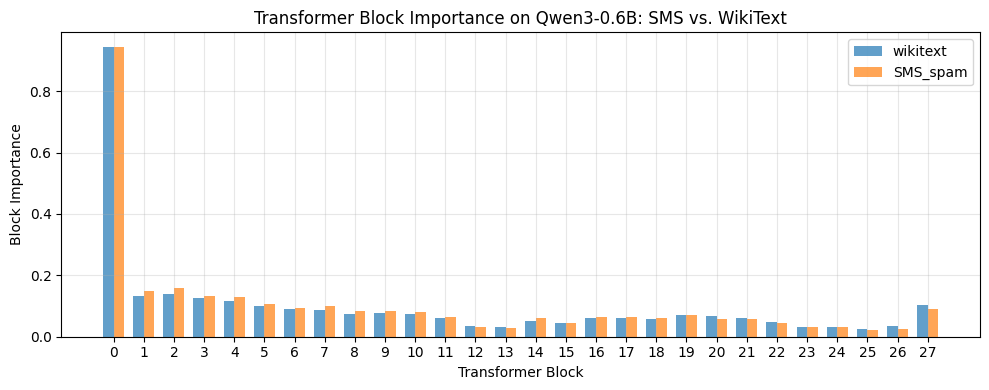

In [26]:
compare_importance(wiki_importance, sms_importance, name1="wikitext", name2="SMS_spam", start=0, end=27)

The results of our comparison reveal a clear pattern. The first layers (0–2) and the last one (27) prove to be important in both datasets, suggesting that they perform fundamental functions, such as the initial processing of the input and the consolidation of the output.

The key difference lies in the behavior of the intermediate layers (roughly 3–26). While in the complex text of Wikitext these layers carry out a measurable job of semantic refinement, in the simple SMS text their contribution is practically null, becoming “passive.” This shows that the importance of a layer varies depending on the complexity of the task, thus validating “depth pruning” as an effective strategy to create more efficient models for specialized tasks.
